# 07 - At-Risk / Churn Prediction

Notebook này đi sâu vào nhóm khách hàng có nguy cơ rời bỏ theo hai hướng song song:
1. **Business criteria**: xác định khách at-risk/churn dựa trên recency, chu kỳ mua, tần suất suy giảm và giá trị đơn hàng đi xuống.
2. **Predictive modeling**: huấn luyện các mô hình dự báo churn với ưu tiên **recall** để hạn chế bỏ sót khách hàng sắp rời bỏ.

**Mục tiêu chính**
- Xác định tiêu chí khách hàng có nguy cơ rời bỏ.
- Huấn luyện và so sánh Logistic Regression, Random Forest, XGBoost, HistGradientBoosting, Extra Trees.
- Đánh giá bằng Accuracy, Precision, Recall, F1-score, ROC-AUC.
- Thiết kế playbook win-back và ưu tiên can thiệp cho nhóm at-risk.


## 1. Set Up Environment and Import Existing Project Modules

Notebook chỉ sử dụng dữ liệu và module đang có sẵn trong project, không sửa file code nào khác.


In [ ]:
import importlib.util
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in [cwd, *cwd.parents]
        if (candidate / 'src').exists() and (candidate / 'data').exists()
    ),
    cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_contract import run_data_contract_checks
from src.features.churn_feature_builder import build_churn_features
from src.features.composite_feature_builder import build_composite_features

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', font_scale=1.0)

HAS_XGBOOST = importlib.util.find_spec('xgboost') is not None
if HAS_XGBOOST:
    from xgboost import XGBClassifier

print('Current working directory:', cwd)
print('Resolved project root:', PROJECT_ROOT)
print('xgboost available:', HAS_XGBOOST)

Current working directory: D:\Data impact\404_Not_Found\Notebook
Resolved project root: D:\Data impact\404_Not_Found
xgboost available: True


## 2. Load Cleaned Data and Build Base Churn Features

Label churn trong notebook này dùng đúng logic hiện có của project:
- chọn `snapshot_date`
- nhìn về tương lai `60 ngày`
- khách nào không còn phát sinh mua sắm trong future window sẽ mang nhãn `churn_label = 1`


In [8]:
DATA_PATH = PROJECT_ROOT / 'data' / 'cleaned' / 'online_retail_cleaned_full.csv'
INACTIVITY_DAYS = 60

raw_df = pd.read_csv(DATA_PATH, parse_dates=['InvoiceDate'])
contract_report = run_data_contract_checks(raw_df)

max_date = raw_df['InvoiceDate'].max()
snapshot_date = max_date - pd.Timedelta(days=INACTIVITY_DAYS)

base_features = build_churn_features(
    raw_df,
    snapshot_date=snapshot_date,
    inactivity_days=INACTIVITY_DAYS,
)
composite_features = build_composite_features(base_features)

sales_df = raw_df.loc[raw_df['Quantity'] > 0].copy()
history_df = sales_df.loc[sales_df['InvoiceDate'] <= snapshot_date].copy()

print('Data contract passed:')
for key, value in contract_report.items():
    print(f'  {key}: {value}')
print(f'\nSnapshot date: {snapshot_date}')
print(f'Base feature shape: {base_features.shape}')
print(f'Churn rate: {base_features["churn_label"].mean():.2%}')

composite_features.head()

Data contract passed:
  rows: 797885
  columns: 28
  date_min: 2009-12-01 07:45:00
  date_max: 2011-12-09 12:50:00

Snapshot date: 2011-10-10 12:50:00
Base feature shape: (5581, 13)
Churn rate: 62.78%


,Customer ID,snapshot_date,recency_days,frequency_90d,monetary_90d,avg_order_value_90d,return_rate_90d,tenure_days,n_unique_days,avg_days_between_orders,day_of_week_mode,recency_velocity,churn_label,purchase_intensity,loyalty_score,retention_score,customer_value_score,churn_risk_index,rfm_segment
0,12346,2011-10-10 12:50:00,265,0,0.0000,0.0000,0.0000,665,11,8.5435,0,0.3985,1,0.0000,0.4770,0.6015,0.1578,0.7475,Hibernating
1,12347,2011-10-10 12:50:00,69,22,584.9100,26.5868,0.0000,343,6,1.6687,1,0.2012,0,0.0641,0.4254,0.7988,0.1647,0.6265,Loyal
2,12348,2011-10-10 12:50:00,14,3,310.0000,103.3333,0.0000,377,5,7.2400,0,0.0371,1,0.0080,0.4612,0.9629,0.1630,0.5982,Loyal
3,12349,2011-10-10 12:50:00,347,0,0.0000,0.0000,0.0000,675,4,3.0755,3,0.5141,0,0.0000,0.4451,0.4859,0.1578,0.7959,Lost
4,12350,2011-10-10 12:50:00,249,0,0.0000,0.0000,0.0000,249,1,0.0000,2,1.0000,1,0.0000,0.3000,0.0000,0.1578,0.7381,Hibernating


## 3. Engineer Cycle-Based Features

Để đi sâu theo hướng **chu kỳ mua**, notebook bổ sung các biến đặc thù:
- chu kỳ mua trung vị / trung bình / độ lệch chuẩn
- tỷ lệ `recency / expected cycle`
- số ngày trễ hơn chu kỳ kỳ vọng
- tốc độ giảm tần suất mua gần đây
- tốc độ giảm chi tiêu gần đây

Những biến này giúp phát hiện khách chưa hẳn đã churn nhưng đang **lệch khỏi nhịp mua bình thường**.


In [9]:
invoice_level = (
    history_df.groupby(['Customer ID', 'Invoice'], as_index=False)
    .agg(
        invoice_date=('InvoiceDate', 'max'),
        invoice_value=('TotalValue', 'sum'),
        invoice_units=('Quantity', 'sum'),
    )
)
invoice_level['invoice_day'] = invoice_level['invoice_date'].dt.normalize()

last30_start = snapshot_date - pd.Timedelta(days=30)
prev60_start = snapshot_date - pd.Timedelta(days=90)
prev60_end = snapshot_date - pd.Timedelta(days=30)

cycle_rows = []
for customer_id, group in invoice_level.groupby('Customer ID'):
    unique_days = np.sort(group['invoice_day'].drop_duplicates().values.astype('datetime64[D]'))
    if len(unique_days) >= 2:
        gaps = np.diff(unique_days).astype(int)
        cycle_median_gap = float(np.median(gaps))
        cycle_mean_gap = float(np.mean(gaps))
        cycle_std_gap = float(np.std(gaps))
    else:
        gaps = np.array([])
        cycle_median_gap = 0.0
        cycle_mean_gap = 0.0
        cycle_std_gap = 0.0

    cycle_cv = float(cycle_std_gap / cycle_mean_gap) if cycle_mean_gap > 0 else 0.0

    recent_30 = group.loc[group['invoice_date'] > last30_start]
    prev_60 = group.loc[(group['invoice_date'] > prev60_start) & (group['invoice_date'] <= prev60_end)]

    orders_last30d = int(recent_30['Invoice'].nunique())
    orders_prev60d = int(prev_60['Invoice'].nunique())
    spend_last30d = float(recent_30['invoice_value'].sum())
    spend_prev60d = float(prev_60['invoice_value'].sum())

    prev30_equiv_orders = orders_prev60d / 2 if orders_prev60d > 0 else 0.0
    prev30_equiv_spend = spend_prev60d / 2 if spend_prev60d > 0 else 0.0

    order_rate_ratio = float((orders_last30d + 0.5) / (prev30_equiv_orders + 0.5))
    spend_rate_ratio = float((spend_last30d + 1.0) / (prev30_equiv_spend + 1.0))
    frequency_momentum = float(orders_last30d - prev30_equiv_orders)
    spend_momentum = float(spend_last30d - prev30_equiv_spend)

    cycle_rows.append({
        'Customer ID': customer_id,
        'cycle_median_gap_days': cycle_median_gap,
        'cycle_mean_gap_days': cycle_mean_gap,
        'cycle_std_gap_days': cycle_std_gap,
        'cycle_cv': cycle_cv,
        'orders_last30d': orders_last30d,
        'orders_prev60d': orders_prev60d,
        'spend_last30d': spend_last30d,
        'spend_prev60d': spend_prev60d,
        'order_rate_ratio': order_rate_ratio,
        'spend_rate_ratio': spend_rate_ratio,
        'frequency_momentum': frequency_momentum,
        'spend_momentum': spend_momentum,
    })

cycle_features = pd.DataFrame(cycle_rows)
model_df = composite_features.merge(cycle_features, on='Customer ID', how='left')

cycle_gap_fallback = model_df['avg_days_between_orders'].fillna(0).clip(lower=0)
model_df['expected_cycle_days'] = np.where(
    model_df['cycle_median_gap_days'].fillna(0) > 0,
    model_df['cycle_median_gap_days'],
    cycle_gap_fallback,
)
model_df['expected_cycle_days'] = pd.Series(model_df['expected_cycle_days']).replace(0, 30.0)
model_df['recency_vs_expected_gap'] = model_df['recency_days'] / model_df['expected_cycle_days']
model_df['days_past_expected_gap'] = model_df['recency_days'] - model_df['expected_cycle_days']
model_df['cycle_break_flag'] = (model_df['recency_vs_expected_gap'] >= 1.5).astype(int)

recency_component = np.clip(model_df['recency_vs_expected_gap'] / 2.5, 0, 1)
frequency_component = np.clip((1.0 - model_df['order_rate_ratio']) / 1.5, 0, 1)
spend_component = np.clip((1.0 - model_df['spend_rate_ratio']) / 1.5, 0, 1)
model_df['cycle_risk_score'] = (0.5 * recency_component + 0.3 * frequency_component + 0.2 * spend_component).round(4)

cycle_cols_preview = [
    'cycle_median_gap_days', 'cycle_mean_gap_days', 'cycle_std_gap_days', 'cycle_cv',
    'order_rate_ratio', 'spend_rate_ratio', 'recency_vs_expected_gap', 'cycle_risk_score'
]
print('Cycle feature snapshot:')
display(model_df[cycle_cols_preview].describe().round(3))

Cycle feature snapshot:


,cycle_median_gap_days,cycle_mean_gap_days,cycle_std_gap_days,cycle_cv,order_rate_ratio,spend_rate_ratio,recency_vs_expected_gap,cycle_risk_score
count,"5,520.0000","5,520.0000","5,520.0000","5,520.0000","5,520.0000","5,520.0000","5,581.0000","5,520.0000"
mean,64.9450,69.8870,25.5520,0.3240,1.2600,72.3950,61.1710,0.3600
std,88.2120,88.0380,36.9620,0.3830,0.9310,272.1130,984.1060,0.1970
min,0.0000,0.0000,0.0000,0.0000,0.0710,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.5530,0.1710
50%,36.0000,45.1120,4.2150,0.0840,1.0000,1.0000,2.1180,0.5000
75%,89.5000,99.7080,41.3350,0.6270,1.0000,1.0000,10.7670,0.5000
max,655.0000,655.0000,311.5000,2.2710,15.0000,"5,201.5000","64,893.0000",0.8190


## 4. Define At-Risk Criteria and Priority Buckets

Khách hàng được xem là **at-risk** nếu bắt đầu lệch đáng kể khỏi nhịp mua thông thường, ví dụ:
- Recency vượt chu kỳ mua kỳ vọng.
- Tần suất mua gần đây giảm.
- Chi tiêu gần đây giảm.
- Đã lâu không quay lại mua hàng.

Phần này tạo thêm `rule-based at-risk score` để dùng song song với mô hình dự báo.


Rule-based at-risk criteria summary:


,at_risk_rule_bucket,customers,churn_rate,recency_days,expected_cycle_days,recency_vs_expected_gap,order_rate_ratio,spend_rate_ratio
0,Low Risk,1272,0.3632,11.0000,42.2500,0.2056,3.0000,129.9800
1,Watchlist,1396,0.5351,75.0000,102.0000,0.9358,0.5000,0.0324
2,At Risk,2913,0.7878,335.0000,30.0000,10.3667,1.0000,1.0000


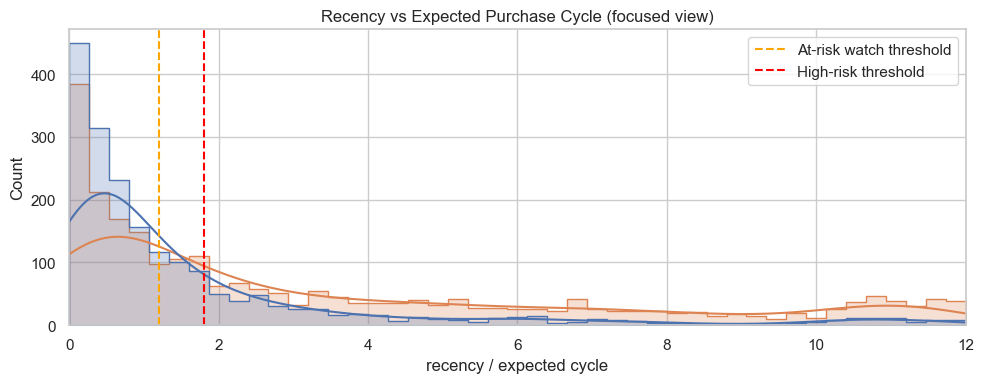

Full max recency_vs_expected_gap: 64893.00
95th percentile: 26.58
Plot capped at: 12.00


In [22]:
model_df['at_risk_rule_score'] = 0
model_df['at_risk_rule_score'] += (model_df['recency_vs_expected_gap'] >= 1.2).astype(int)
model_df['at_risk_rule_score'] += (model_df['recency_vs_expected_gap'] >= 1.8).astype(int)
model_df['at_risk_rule_score'] += (model_df['order_rate_ratio'] < 0.75).astype(int)
model_df['at_risk_rule_score'] += (model_df['spend_rate_ratio'] < 0.80).astype(int)
model_df['at_risk_rule_score'] += (model_df['recency_days'] >= 90).astype(int)
model_df['at_risk_rule_score'] += (model_df['frequency_90d'] <= 1).astype(int)

model_df['at_risk_rule_bucket'] = pd.cut(
    model_df['at_risk_rule_score'],
    bins=[-0.1, 1, 3, 6],
    labels=['Low Risk', 'Watchlist', 'At Risk'],
)

criteria_view = (
    model_df.groupby('at_risk_rule_bucket', observed=False)
    .agg(
        customers=('Customer ID', 'nunique'),
        churn_rate=('churn_label', 'mean'),
        recency_days=('recency_days', 'median'),
        expected_cycle_days=('expected_cycle_days', 'median'),
        recency_vs_expected_gap=('recency_vs_expected_gap', 'median'),
        order_rate_ratio=('order_rate_ratio', 'median'),
        spend_rate_ratio=('spend_rate_ratio', 'median'),
    )
    .reset_index()
)

print('Rule-based at-risk criteria summary:')
display(criteria_view)

plot_q95 = model_df['recency_vs_expected_gap'].quantile(0.95)
plot_cap = min(float(plot_q95), 12.0)
plot_df = model_df.loc[model_df['recency_vs_expected_gap'] <= plot_cap].copy()

plt.figure(figsize=(10, 4))
sns.histplot(data=plot_df, x='recency_vs_expected_gap', hue='churn_label', bins=45, kde=True, element='step')
plt.axvline(1.2, color='orange', linestyle='--', linewidth=1.5, label='At-risk watch threshold')
plt.axvline(1.8, color='red', linestyle='--', linewidth=1.5, label='High-risk threshold')
plt.title('Recency vs Expected Purchase Cycle (focused view)')
plt.xlabel('recency / expected cycle')
plt.xlim(0, plot_cap)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Full max recency_vs_expected_gap: {model_df["recency_vs_expected_gap"].max():.2f}')
print(f'95th percentile: {plot_q95:.2f}')
print(f'Plot capped at: {plot_cap:.2f}')

## 5. Prepare Modeling Dataset

Để đánh giá mô hình công bằng và bám mục tiêu business, notebook sẽ:
- chia dữ liệu thành `train / validation / test`
- tối ưu threshold trên validation set
- đánh giá chính thức trên test set
- ưu tiên **recall** trước, sau đó mới xét precision, F1 và ROC-AUC


In [16]:
base_numeric_features = [
    'recency_days', 'frequency_90d', 'monetary_90d', 'avg_order_value_90d',
    'return_rate_90d', 'tenure_days', 'n_unique_days', 'avg_days_between_orders',
    'day_of_week_mode', 'recency_velocity',
]
composite_numeric_features = [
    'purchase_intensity', 'loyalty_score', 'retention_score',
    'customer_value_score', 'churn_risk_index',
]
cycle_numeric_features = [
    'cycle_median_gap_days', 'cycle_mean_gap_days', 'cycle_std_gap_days', 'cycle_cv',
    'orders_last30d', 'orders_prev60d', 'spend_last30d', 'spend_prev60d',
    'order_rate_ratio', 'spend_rate_ratio', 'frequency_momentum', 'spend_momentum',
    'expected_cycle_days', 'recency_vs_expected_gap', 'days_past_expected_gap',
    'cycle_break_flag', 'cycle_risk_score', 'at_risk_rule_score',
]
cat_features = ['rfm_segment', 'at_risk_rule_bucket']

full_features = base_numeric_features + composite_numeric_features + cycle_numeric_features + cat_features
cycle_only_features = cycle_numeric_features + ['recency_days', 'avg_days_between_orders']

model_df = model_df.replace([np.inf, -np.inf], np.nan)
y = model_df['churn_label'].astype(int)

train_df, temp_df = train_test_split(
    model_df,
    test_size=0.40,
    stratify=y,
    random_state=42,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['churn_label'],
    random_state=42,
)

print('Dataset split sizes:')
print('  Train:', train_df.shape)
print('  Validation:', val_df.shape)
print('  Test:', test_df.shape)
print('  Train churn rate:', train_df['churn_label'].mean())
print('  Validation churn rate:', val_df['churn_label'].mean())
print('  Test churn rate:', test_df['churn_label'].mean())

Dataset split sizes:
  Train: (3348, 38)
  Validation: (1116, 38)
  Test: (1117, 38)
  Train churn rate: 0.6278375149342891
  Validation churn rate: 0.6281362007168458
  Test churn rate: 0.6275738585496866


## 6. Train and Compare Churn Models

Các mô hình được so sánh:
- Logistic Regression (cycle-only baseline)
- Logistic Regression (full feature set)
- Random Forest
- Extra Trees
- HistGradientBoosting
- XGBoost nếu thư viện khả dụng


In [17]:
def make_preprocessor(numeric_features: list[str], categorical_features: list[str], scale_numeric: bool) -> ColumnTransformer:
    numeric_steps = [
        ('imputer', SimpleImputer(strategy='median')),
    ]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))

    return ColumnTransformer(
        transformers=[
            ('num', Pipeline(numeric_steps), numeric_features),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
            ]), categorical_features),
        ],
        remainder='drop',
    )


def tune_threshold_for_recall(y_true: pd.Series, y_prob: np.ndarray, min_precision: float = 0.30):
    rows = []
    for threshold in np.linspace(0.10, 0.90, 81):
        pred = (y_prob >= threshold).astype(int)
        rows.append({
            'threshold': threshold,
            'accuracy': accuracy_score(y_true, pred),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0),
            'f1': f1_score(y_true, pred, zero_division=0),
        })
    threshold_df = pd.DataFrame(rows)
    eligible = threshold_df.loc[threshold_df['precision'] >= min_precision]
    if eligible.empty:
        eligible = threshold_df.copy()
    best = eligible.sort_values(['recall', 'f1', 'precision'], ascending=[False, False, False]).iloc[0]
    return float(best['threshold']), threshold_df


def evaluate_predictions(y_true: pd.Series, y_prob: np.ndarray, threshold: float) -> dict:
    pred = (y_prob >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
    }


def make_model_specs(scale_pos_weight: float):
    specs = [
        {
            'model': 'Logistic Regression (cycle-only)',
            'features': cycle_only_features,
            'numeric_features': cycle_only_features,
            'categorical_features': [],
            'builder': lambda: Pipeline([
                ('prep', make_preprocessor(cycle_only_features, [], scale_numeric=True)),
                ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)),
            ]),
        },
        {
            'model': 'Logistic Regression (full)',
            'features': full_features,
            'numeric_features': base_numeric_features + composite_numeric_features + cycle_numeric_features,
            'categorical_features': cat_features,
            'builder': lambda: Pipeline([
                ('prep', make_preprocessor(base_numeric_features + composite_numeric_features + cycle_numeric_features, cat_features, scale_numeric=True)),
                ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)),
            ]),
        },
        {
            'model': 'Random Forest',
            'features': full_features,
            'numeric_features': base_numeric_features + composite_numeric_features + cycle_numeric_features,
            'categorical_features': cat_features,
            'builder': lambda: Pipeline([
                ('prep', make_preprocessor(base_numeric_features + composite_numeric_features + cycle_numeric_features, cat_features, scale_numeric=False)),
                ('model', RandomForestClassifier(
                    n_estimators=350,
                    max_depth=None,
                    min_samples_leaf=5,
                    class_weight='balanced_subsample',
                    random_state=42,
                    n_jobs=-1,
                )),
            ]),
        },
        {
            'model': 'Extra Trees',
            'features': full_features,
            'numeric_features': base_numeric_features + composite_numeric_features + cycle_numeric_features,
            'categorical_features': cat_features,
            'builder': lambda: Pipeline([
                ('prep', make_preprocessor(base_numeric_features + composite_numeric_features + cycle_numeric_features, cat_features, scale_numeric=False)),
                ('model', ExtraTreesClassifier(
                    n_estimators=400,
                    min_samples_leaf=4,
                    class_weight='balanced',
                    random_state=42,
                    n_jobs=-1,
                )),
            ]),
        },
        {
            'model': 'HistGradientBoosting',
            'features': full_features,
            'numeric_features': base_numeric_features + composite_numeric_features + cycle_numeric_features,
            'categorical_features': cat_features,
            'builder': lambda: Pipeline([
                ('prep', make_preprocessor(base_numeric_features + composite_numeric_features + cycle_numeric_features, cat_features, scale_numeric=False)),
                ('model', HistGradientBoostingClassifier(
                    learning_rate=0.05,
                    max_depth=6,
                    max_iter=250,
                    random_state=42,
                )),
            ]),
        },
    ]

    if HAS_XGBOOST:
        specs.append(
            {
                'model': 'XGBoost',
                'features': full_features,
                'numeric_features': base_numeric_features + composite_numeric_features + cycle_numeric_features,
                'categorical_features': cat_features,
                'builder': lambda: Pipeline([
                    ('prep', make_preprocessor(base_numeric_features + composite_numeric_features + cycle_numeric_features, cat_features, scale_numeric=False)),
                    ('model', XGBClassifier(
                        n_estimators=350,
                        max_depth=4,
                        learning_rate=0.05,
                        subsample=0.90,
                        colsample_bytree=0.80,
                        reg_lambda=1.0,
                        objective='binary:logistic',
                        eval_metric='logloss',
                        random_state=42,
                        scale_pos_weight=scale_pos_weight,
                    )),
                ]),
            }
        )
    return specs

pos_count = train_df['churn_label'].sum()
neg_count = len(train_df) - pos_count
scale_pos_weight = float(neg_count / pos_count) if pos_count else 1.0
model_specs = make_model_specs(scale_pos_weight)

results = []
model_artifacts = {}

for spec in model_specs:
    model = spec['builder']()
    model.fit(train_df[spec['features']], train_df['churn_label'])

    val_prob = model.predict_proba(val_df[spec['features']])[:, 1]
    best_threshold, threshold_grid = tune_threshold_for_recall(val_df['churn_label'], val_prob, min_precision=0.30)

    test_prob = model.predict_proba(test_df[spec['features']])[:, 1]
    metrics = evaluate_predictions(test_df['churn_label'], test_prob, best_threshold)

    results.append({
        'model': spec['model'],
        'threshold': best_threshold,
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'roc_auc': metrics['roc_auc'],
    })
    model_artifacts[spec['model']] = {
        'model': model,
        'features': spec['features'],
        'threshold_grid': threshold_grid,
        'threshold': best_threshold,
        'test_prob': test_prob,
    }

results_df = pd.DataFrame(results).sort_values(['recall', 'f1', 'roc_auc'], ascending=[False, False, False])
print('Model comparison on test set:')
display(results_df)

Model comparison on test set:


,model,threshold,accuracy,precision,recall,f1,roc_auc
2,Random Forest,0.1000,0.6831,0.6651,0.9971,0.7979,0.8010
3,Extra Trees,0.1000,0.6741,0.6591,0.9957,0.7932,0.7988
0,Logistic Regression (cycle-only),0.1000,0.6643,0.6523,0.9957,0.7883,0.7941
1,Logistic Regression (full),0.1100,0.6893,0.6705,0.9929,0.8005,0.7979
5,XGBoost,0.1000,0.7028,0.6821,0.9857,0.8063,0.7988
4,HistGradientBoosting,0.1200,0.6965,0.6781,0.9829,0.8026,0.7903


## 7. Inspect the Best Model with Recall Priority

Do bài toán này ưu tiên không bỏ sót khách rời bỏ, model tốt nhất sẽ được chọn theo **Recall** trước, sau đó mới xét F1 và ROC-AUC.


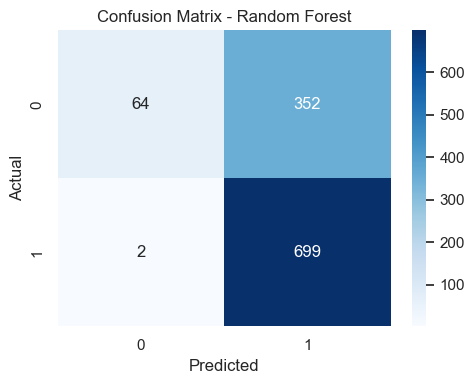

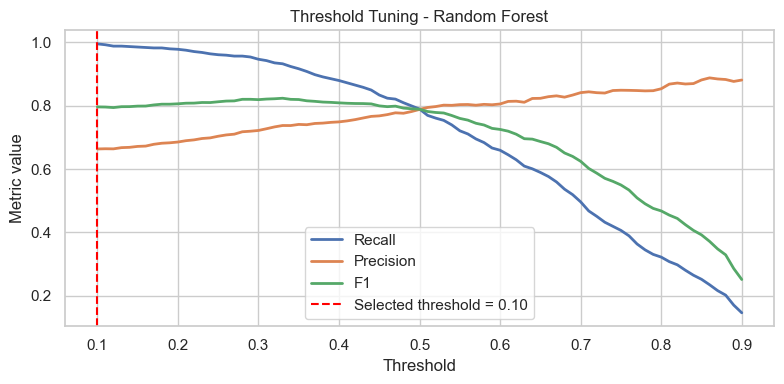

Best model by recall-first ranking: Random Forest
Selected threshold: 0.10


,feature,importance
14,num__churn_risk_index,0.0873
0,num__recency_days,0.0728
29,num__days_past_expected_gap,0.0676
1,num__frequency_90d,0.0560
9,num__recency_velocity,0.0475
13,num__customer_value_score,0.0467
10,num__purchase_intensity,0.0464
12,num__retention_score,0.0449
28,num__recency_vs_expected_gap,0.0413
7,num__avg_days_between_orders,0.0378


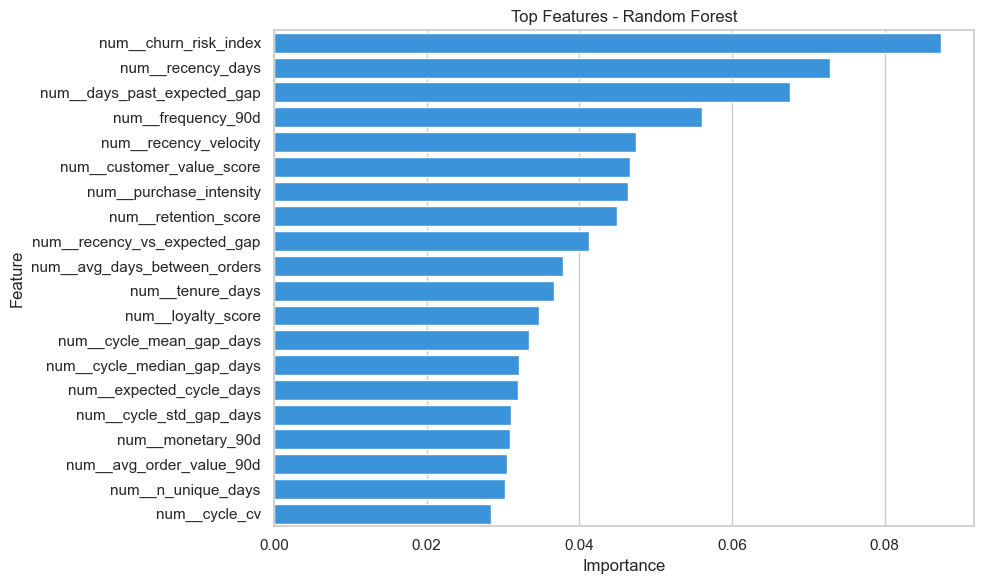

In [19]:
best_model_name = results_df.iloc[0]['model']
best_artifact = model_artifacts[best_model_name]
best_model = best_artifact['model']
best_threshold = best_artifact['threshold']
best_test_prob = best_artifact['test_prob']
best_test_pred = (best_test_prob >= best_threshold).astype(int)

cm = confusion_matrix(test_df['churn_label'], best_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

threshold_curve = best_artifact['threshold_grid']
plt.figure(figsize=(8, 4))
plt.plot(threshold_curve['threshold'], threshold_curve['recall'], label='Recall', linewidth=2)
plt.plot(threshold_curve['threshold'], threshold_curve['precision'], label='Precision', linewidth=2)
plt.plot(threshold_curve['threshold'], threshold_curve['f1'], label='F1', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Selected threshold = {best_threshold:.2f}')
plt.title(f'Threshold Tuning - {best_model_name}')
plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.legend()
plt.tight_layout()
plt.show()

prep = best_model.named_steps['prep']
feature_names = prep.get_feature_names_out()
estimator = best_model.named_steps['model']
if hasattr(estimator, 'feature_importances_'):
    importance_values = estimator.feature_importances_
elif hasattr(estimator, 'coef_'):
    importance_values = np.abs(estimator.coef_[0])
else:
    importance_values = np.zeros(len(feature_names))

importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importance_values})
    .sort_values('importance', ascending=False)
    .head(20)
)

print(f'Best model by recall-first ranking: {best_model_name}')
print(f'Selected threshold: {best_threshold:.2f}')
display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', color='#2196F3')
plt.title(f'Top Features - {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Score All Customers and Build Win-Back Recommendations

Sau khi chọn mô hình tốt nhất, notebook sẽ chấm điểm toàn bộ khách hàng để:
- xếp hạng ưu tiên can thiệp
- đề xuất chiến dịch win-back
- gợi ý sản phẩm phễu giá thấp, dễ quyết định
- gắn thêm tín hiệu theo chu kỳ mua để quyết định mức độ khẩn cấp


In [20]:
feature_map = {spec['model']: spec['features'] for spec in model_specs}
best_features = feature_map[best_model_name]

trainval_df = pd.concat([train_df, val_df], ignore_index=True)
scale_pos_weight_final = float((len(trainval_df) - trainval_df['churn_label'].sum()) / trainval_df['churn_label'].sum())
final_specs = {spec['model']: spec for spec in make_model_specs(scale_pos_weight_final)}
final_model = final_specs[best_model_name]['builder']()
final_model.fit(trainval_df[best_features], trainval_df['churn_label'])

scored_df = model_df.copy()
scored_df['churn_probability'] = final_model.predict_proba(scored_df[best_features])[:, 1]
scored_df['predicted_churn'] = (scored_df['churn_probability'] >= best_threshold).astype(int)

priority_conditions = [
    (scored_df['churn_probability'] >= 0.80) | (scored_df['cycle_risk_score'] >= 0.75),
    (scored_df['churn_probability'] >= 0.65) | (scored_df['recency_vs_expected_gap'] >= 1.5),
    (scored_df['churn_probability'] >= 0.50) | (scored_df['at_risk_rule_bucket'] == 'At Risk'),
]
priority_labels = ['P1 - Urgent Win-back', 'P2 - Strong Reminder', 'P3 - Soft Reminder']
scored_df['intervention_priority'] = np.select(priority_conditions, priority_labels, default='Monitor')

last_purchase = (
    history_df.sort_values('InvoiceDate')
    .groupby('Customer ID')
    .tail(1)[['Customer ID', 'Description']]
    .rename(columns={'Description': 'last_product'})
)
scored_df = scored_df.merge(last_purchase, on='Customer ID', how='left')
scored_df['last_product'] = scored_df['last_product'].fillna('Unknown Product')

price_cap = history_df['Price'].quantile(0.35)
funnel_pool = (
    history_df.loc[history_df['Price'] <= price_cap]
    .groupby('Description', as_index=False)
    .agg(
        customers=('Customer ID', 'nunique'),
        orders=('Invoice', 'nunique'),
        median_price=('Price', 'median'),
    )
    .sort_values(['customers', 'orders'], ascending=False)
)

global_funnel_products = funnel_pool['Description'].head(5).tolist()

if 'ProductCategory' in history_df.columns:
    last_category = (
        history_df.sort_values('InvoiceDate')
        .groupby('Customer ID')
        .tail(1)[['Customer ID', 'ProductCategory']]
        .rename(columns={'ProductCategory': 'last_category'})
    )
    scored_df = scored_df.merge(last_category, on='Customer ID', how='left')

    category_funnel = (
        history_df.loc[history_df['Price'] <= price_cap]
        .groupby(['ProductCategory', 'Description'], as_index=False)
        .agg(customers=('Customer ID', 'nunique'), orders=('Invoice', 'nunique'))
        .sort_values(['ProductCategory', 'customers', 'orders'], ascending=[True, False, False])
    )
    category_funnel_map = (
        category_funnel.groupby('ProductCategory')['Description']
        .apply(lambda s: list(s.head(3)))
        .to_dict()
    )
else:
    scored_df['last_category'] = 'Unknown'
    category_funnel_map = {}


def pick_funnel_products(row: pd.Series) -> str:
    items = category_funnel_map.get(row['last_category'], global_funnel_products[:3])
    return ', '.join(items[:3]) if items else 'No low-friction product found'


def recommend_action(row: pd.Series) -> str:
    if row['intervention_priority'] == 'P1 - Urgent Win-back':
        return 'Email chăm sóc + voucher mạnh + nhắc đúng chu kỳ + gợi ý sản phẩm phễu'
    if row['intervention_priority'] == 'P2 - Strong Reminder':
        return 'Reminder cá nhân hóa + ưu đãi vừa phải + bundle dễ mua'
    if row['intervention_priority'] == 'P3 - Soft Reminder':
        return 'Soft reminder + gợi ý bestseller giá thấp + nội dung giáo dục'
    return 'Monitor only'

scored_df['funnel_products'] = scored_df.apply(pick_funnel_products, axis=1)
scored_df['winback_action'] = scored_df.apply(recommend_action, axis=1)

at_risk_recommendations = (
    scored_df.loc[scored_df['intervention_priority'] != 'Monitor', [
        'Customer ID', 'intervention_priority', 'churn_probability', 'at_risk_rule_bucket',
        'cycle_risk_score', 'recency_vs_expected_gap', 'last_product', 'last_category',
        'funnel_products', 'winback_action', 'rfm_segment', 'customer_value_score'
    ]]
    .sort_values(['intervention_priority', 'churn_probability'], ascending=[True, False])
)

print('At-risk recommendation sample:')
display(at_risk_recommendations.head(20))

At-risk recommendation sample:


,Customer ID,intervention_priority,churn_probability,at_risk_rule_bucket,cycle_risk_score,recency_vs_expected_gap,last_product,last_category,funnel_products,winback_action,rfm_segment,customer_value_score
35,12382,P1 - Urgent Win-back,0.9923,At Risk,NaN,20.7000,Unknown Product,NaN,"60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK P...",Email chăm sóc + voucher mạnh + nhắc đúng chu ...,Lost,0.1578
325,12706,P1 - Urgent Win-back,0.9923,At Risk,NaN,20.7000,Unknown Product,NaN,"60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK P...",Email chăm sóc + voucher mạnh + nhắc đúng chu ...,Lost,0.1578
654,13054,P1 - Urgent Win-back,0.9923,At Risk,NaN,20.7000,Unknown Product,NaN,"60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK P...",Email chăm sóc + voucher mạnh + nhắc đúng chu ...,Lost,0.1578
1102,13528,P1 - Urgent Win-back,0.9923,At Risk,NaN,20.7000,Unknown Product,NaN,"60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK P...",Email chăm sóc + voucher mạnh + nhắc đúng chu ...,Lost,0.1578
1233,13664,P1 - Urgent Win-back,0.9923,At Risk,NaN,20.7000,Unknown Product,NaN,"60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK P...",Email chăm sóc + voucher mạnh + nhắc đúng chu ...,Lost,0.1578
2827,15357,P1 - Urgent Win-back,0.9923,At Risk,NaN,20.7000,Unknown Product,NaN,"60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK P...",Email chăm sóc + voucher mạnh + nhắc đúng chu ...,Lost,0.1578
2852,15383,P1 - Urgent Win-back,0.9923,At Risk,NaN,20.7000,Unknown Product,NaN,"60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK P...",Email chăm sóc + voucher mạnh + nhắc đúng chu ...,Lost,0.1578
3572,16154,P1 - Urgent Win-back,0.9923,At Risk,NaN,20.7000,Unknown Product,NaN,"60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK P...",Email chăm sóc + voucher mạnh + nhắc đúng chu ...,Lost,0.1578
3970,16575,P1 - Urgent Win-back,0.9923,At Risk,NaN,20.7000,Unknown Product,NaN,"60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK P...",Email chăm sóc + voucher mạnh + nhắc đúng chu ...,Lost,0.1578
4502,17130,P1 - Urgent Win-back,0.9923,At Risk,NaN,20.7000,Unknown Product,NaN,"60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK P...",Email chăm sóc + voucher mạnh + nhắc đúng chu ...,Lost,0.1578


## 9. Final Business Reading

Kết luận cuối nên trả lời 4 câu hỏi:
1. Tiêu chí at-risk/churn nào đang tách nhóm tốt nhất?
2. Model nào cho recall tốt nhất mà vẫn giữ precision chấp nhận được?
3. Feature nào quan trọng nhất trong việc dự báo churn?
4. Nên ưu tiên campaign win-back thế nào theo từng mức độ rủi ro?


In [21]:
priority_summary = (
    scored_df.groupby('intervention_priority', observed=False)
    .agg(
        customers=('Customer ID', 'nunique'),
        avg_churn_probability=('churn_probability', 'mean'),
        avg_cycle_risk_score=('cycle_risk_score', 'mean'),
        actual_churn_rate=('churn_label', 'mean'),
        median_customer_value=('customer_value_score', 'median'),
    )
    .reset_index()
    .sort_values('avg_churn_probability', ascending=False)
)

playbook = pd.DataFrame([
    {'priority': 'P1 - Urgent Win-back', 'goal': 'Ngăn churn ngay', 'recommended_tactic': 'Email + voucher mạnh + nhắc đúng chu kỳ + sản phẩm phễu'},
    {'priority': 'P2 - Strong Reminder', 'goal': 'Kéo khách quay lại sớm', 'recommended_tactic': 'Reminder cá nhân hóa + bundle nhẹ + ưu đãi vừa phải'},
    {'priority': 'P3 - Soft Reminder', 'goal': 'Khơi gợi mua lại', 'recommended_tactic': 'Soft reminder + bestseller giá thấp + nội dung gợi ý'},
    {'priority': 'Monitor', 'goal': 'Theo dõi', 'recommended_tactic': 'Giữ liên lạc định kỳ, chưa cần khuyến mãi mạnh'},
])

print('Priority summary:')
display(priority_summary)
print('\nWin-back playbook:')
display(playbook)

print('\nKey takeaways:')
print(f'- Best recall-first model: {best_model_name}')
print(f'- Operating threshold: {best_threshold:.2f}')
print(f'- Share flagged for intervention: {(scored_df["intervention_priority"] != "Monitor").mean():.2%}')
print(f'- Median recency vs expected cycle for flagged customers: {scored_df.loc[scored_df["intervention_priority"] != "Monitor", "recency_vs_expected_gap"].median():.2f}')

Priority summary:


,intervention_priority,customers,avg_churn_probability,avg_cycle_risk_score,actual_churn_rate,median_customer_value
1,P1 - Urgent Win-back,1491,0.8827,0.4695,0.9618,0.1578
2,P2 - Strong Reminder,2182,0.6057,0.4450,0.6732,0.1578
3,P3 - Soft Reminder,417,0.5747,0.1775,0.8082,0.1618
0,Monitor,1491,0.2270,0.1811,0.1771,0.1662



Win-back playbook:


,priority,goal,recommended_tactic
0,P1 - Urgent Win-back,Ngăn churn ngay,Email + voucher mạnh + nhắc đúng chu kỳ + sản ...
1,P2 - Strong Reminder,Kéo khách quay lại sớm,Reminder cá nhân hóa + bundle nhẹ + ưu đãi vừa...
2,P3 - Soft Reminder,Khơi gợi mua lại,Soft reminder + bestseller giá thấp + nội dung...
3,Monitor,Theo dõi,"Giữ liên lạc định kỳ, chưa cần khuyến mãi mạnh"



Key takeaways:
- Best recall-first model: Random Forest
- Operating threshold: 0.10
- Share flagged for intervention: 73.28%
- Median recency vs expected cycle for flagged customers: 5.07
